<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXVodWNsM3Bia3duZGljZzRqMTI2MGFiZjlkZzBwcmhuaWxydjlpaiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AOSwwqVjNZlDO/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:#ffffff; margin-top:15px;"><b>Manual Flexural Method. all deformations</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Matrix Analisys</p>
  <p><b>Year:</b> APRIL - 2026</p>

</div>

#### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from repo_maxtrix_analisys import *

![alt text](image-3.png)

#### Data

In [3]:
w = 2                       # T/m
L = 4                       # m
vb = 0.30                   # m
vh = 0.30                   # m
E = 2100000                 # T/m2
T1 = 9                      # celcius
T2 = 18                     # celcius
alfa = 9.9e-6               # m/m/celcius 
dP = 0.008                  # previus deformation
dR1 = 0.001                 # rad
dR2 = 0.009                 # m
dR3 = 0.012                 # m

#------- Geometry---------
XF = np.array([0, L/2, 0.99*L, 1.01*L, L + L/2, L + 0.99*L, L + 1.01*L, 2*L + L/2, 3*L])
YF = np.zeros(len(XF))

XV = np.array([0, L/2, 1.00*L, 1.00*L, L + L/2, L + 1.00*L, L + 1.00*L, 2*L + 1.00*L/2, 2*L + 1.00*L/2, 3*L])
YV = np.zeros(len(XV))

#### Calculations

In [4]:
I = vb*vh**3 / 12

##### Flex Matrix
![alt text](image-4.png)

In [5]:
F11 = L / (3*E*I)
F21 = -L / (6*E*I)
F31 = 0
F12 = F21
F22 = 2*L / (3*E*I)
F32 = L / (6*E*I)
F13 = F31
F23 = F32
F33 = 2*L / (3*E*I)

F = np.array([[F11, F12, F13],
              [F21, F22, F23],
              [F31, F32, F33]])

F_df = pd.DataFrame(F, columns=['Q1','Q2','Q3'], index = ['Q1','Q2','Q3'])
F_df

,Q1,Q2,Q3
Q1,0.000941,-0.000470,0.000000
Q2,-0.000470,0.001881,0.000470
Q3,0.000000,0.000470,0.001881


##### Displacement vector corresponding to the redundants in the real structure $\{D_Q\}$
![alt text](image-5.png)

In [6]:
DQ = np.array([[-dR1],
               [0],
               [0]])

DQ_df = pd.DataFrame(DQ, columns=['DQ'], index = ['Q1','Q2','Q3'])
DQ_df

,DQ
Q1,-0.001
Q2,0.000
Q3,0.000


##### Displacement vector corresponding to the redundants due to real loads in the released or statically determinate structure

$$ \{D_{QL}\}=
\begin{bmatrix}
D_{QL1} \\
D_{QL2} \\
\vdots \\
D_{QLn}
\end{bmatrix}
$$

In [7]:
DQL = np.array([[-w*L**3 / (24*E*I)],
                [w*L**3 / (24*E*I)],
                [w*L**3 / (16*E*I)]])

DQL_df = pd.DataFrame(DQL, columns=['DQL'], index = ['Q1','Q2','Q3'])
DQL_df

,DQL
Q1,-0.003762
Q2,0.003762
Q3,0.005644


##### Displacement vector corresponding to the redundants due to temperature effects in the released or statically determinate structure

$$\{D_{QT}\}=
\begin{bmatrix}
D_{QT1} \\
D_{QT2} \\
\vdots \\
D_{QTn}
\end{bmatrix}
$$

In [8]:
DQT = L /2 * (alfa*(T1-T2)) / vh * np.array([[-1],
                                             [2],
                                             [2]])

DQT_df = pd.DataFrame(DQT, columns=['DQT'], index = ['Q1','Q2','Q3'])
DQT_df

,DQT
Q1,0.000594
Q2,-0.001188
Q3,-0.001188


##### Displacement vector corresponding to the redundants due to initial deformations in the released or statically determinate structure

$$ \{D_{QP}\}\begin{bmatrix}
D_{QP1} \\
D_{QP2} \\
\vdots \\
D_{QPn}
\end{bmatrix}
$$

In [9]:
DQP = np.array([[0],
                [dP/L],
                [-2*dP/L]])

DQP_df = pd.DataFrame(DQP, columns=['DQP'], index = ['Q1','Q2','Q3'])
DQP_df

,DQP
Q1,0.000
Q2,0.002
Q3,-0.004


##### Displacement vector corresponding to the redundants due to support displacements in the released or statically determinate structure

$$\{D_{QR}\}=
\begin{bmatrix}
D_{QR1} \\
D_{QR2} \\
\vdots \\
D_{QRn}
\end{bmatrix}
$$

In [10]:
DQR = np.array([[-dR2/L],
                [-2*dR2/L + dR3/L],
                [dR2/L - 2*dR3/L]])

DQR_df = pd.DataFrame(DQR, columns=['DQR'], index = ['Q1','Q2','Q3'])
DQR_df

,DQR
Q1,-0.00225
Q2,-0.00150
Q3,-0.00375


#### Total displacement vector corresponding to the redundants in the released or statically determinate structure

$$\{D_{QS}\}=
\{D_{QL}\}
+
\{D_{QT}\}
+
\{D_{QP}\}
+
\{D_{QR}\}
$$

In [11]:
DQS = DQL + DQT + DQP + DQR

DQS_df = pd.DataFrame(DQS, columns=['DQS'], index = ['Q1','Q2','Q3'])
DQS_df

,DQS
Q1,-0.005418
Q2,0.003074
Q3,-0.003294


#### Calculation of redundants

$$\{Q\}=[F]^{-1}\left(\{D_Q\}-\{D_{QS}\}\right)
$$

In [12]:
#------------Due all deformations---------------
Q_all = np.linalg.inv(F) @ (DQ - DQS)
Q_all_df = pd.DataFrame(Q_all, columns=['Q due all deformations'])
#------------only due real loads---------------
Q_L = np.linalg.inv(F) @ (0 - DQL)
Q_L_df = pd.DataFrame(Q_L, columns=['Q due real loads'])
#------------only due climate effects---------------
Q_T = np.linalg.inv(F) @ (0 - DQT)
Q_T_df = pd.DataFrame(Q_T, columns=['Q due climate effects'])
#------------only due previus defformations---------------
Q_P = np.linalg.inv(F) @ (0 - DQP)
Q_P_df = pd.DataFrame(Q_P, columns=['Q due previus defformations'])
#------------only due support diplacement---------------
Q_R = np.linalg.inv(F) @ (0 - DQR)
Q_R_df = pd.DataFrame(Q_R, columns=['Q due support diplacement'])

Q = pd.concat([Q_all_df, Q_L_df, Q_T_df, Q_P_df, Q_R_df], axis = 1, ignore_index= False)
Q

,Q due all deformations,Q due real loads,Q due climate effects,Q due previus defformations,Q due support diplacement
0,4.144974,3.846154,-0.437190,-0.981346,2.944038
1,-1.104872,-0.307692,0.388613,-1.962692,1.104014
2,2.027324,-2.923077,0.534343,2.616923,1.717356


#### Member action vector (flexure) in the real structure

$$\{AM\}=
\{AM_L\}
+
[AM_Q]\{Q\}
$$

Where:

- $\{AM\}$ = member action vector (flexure) in the real structure.
- $\{AM_L\}$ = member action vector (flexure) due to real loads in the released or statically determinate structure.
- $[AM_Q]$ = member action matrix (flexure) due to unit redundants in the released or statically determinate structure.
- $\{Q\}$ = vector of redundants.

![alt text](image-6.png)

##### Calculation of Member action vector (flexure) due to real loads in the released or statically determinate structure $\{AM\}$
![alt text](image-7.png)

In [13]:
AML = np.array([[0],
                [w*L**(2)/8],
                [0],
                [0],
                [0],
                [0],
                [0],
                [w*L**(2)/4],
                [0],
                ])

##### Calculation of Member action matrix (flexure) due to unit redundants in the released or statically determinate structure. $[AM_Q]$
![alt text](image-8.png)

In [14]:
AMQ = np.array([[-1, 0, 0],
                [-1/2, 1/2, 0],
                [0, 1, 0],
                [0, 1, 0],
                [0, 1/2, 1/2],
                [0, 0, 1],
                [0, 0, 1],
                [0, 0, 1/2],
                [0, 0, 0],
                ])

##### Calculation of Member action vector (flexure) in the real structure $\{AM\} = \{AM_L\}+[AM_Q]\{Q\}$.

In [15]:
#------------Due all deformations---------------
AM_all = AML + (AMQ @ Q_all)
AM_all_df = pd.DataFrame(AM_all, columns=['AM due all deformations'])
#------------only due real loads---------------
AM_L = AML + (AMQ @ Q_L)
AM_L_df = pd.DataFrame(AM_L, columns=['AM due real loads'])
#------------only due climate effects---------------
AM_T = AML + (AMQ @ Q_T)
AM_T_df = pd.DataFrame(AM_T, columns=['AM due climate effects'])
#------------only due previus defformations---------------
AM_P = AML + (AMQ @ Q_P)
AM_P_df = pd.DataFrame(AM_P, columns=['AM due previus defformations'])
#------------only due support diplacement---------------
AM_R = AML + (AMQ @ Q_R)
AM_R_df = pd.DataFrame(AM_R, columns=['AM due support displacement'])

AM = pd.concat([AM_all_df, AM_L_df, AM_T_df, AM_P_df, AM_R_df], axis = 1, ignore_index= False)
AM


,AM due all deformations,AM due real loads,AM due climate effects,AM due previus defformations,AM due support displacement
0,-4.144974,-3.846154,0.437190,0.981346,-2.944038
1,1.375077,1.923077,4.412901,3.509327,3.079988
2,-1.104872,-0.307692,0.388613,-1.962692,1.104014
3,-1.104872,-0.307692,0.388613,-1.962692,1.104014
4,0.461226,-1.615385,0.461478,0.327115,1.410685
5,2.027324,-2.923077,0.534343,2.616923,1.717356
6,2.027324,-2.923077,0.534343,2.616923,1.717356
7,9.013662,6.538462,8.267171,9.308462,8.858678
8,0.000000,0.000000,0.000000,0.000000,0.000000


##### For Plotting - FLEXION

In [16]:
AM_all = AM_all * -1
AM_L = AM_L * -1
AM_T = AM_T * -1
AM_P = AM_P * -1
AM_R = AM_R * -1

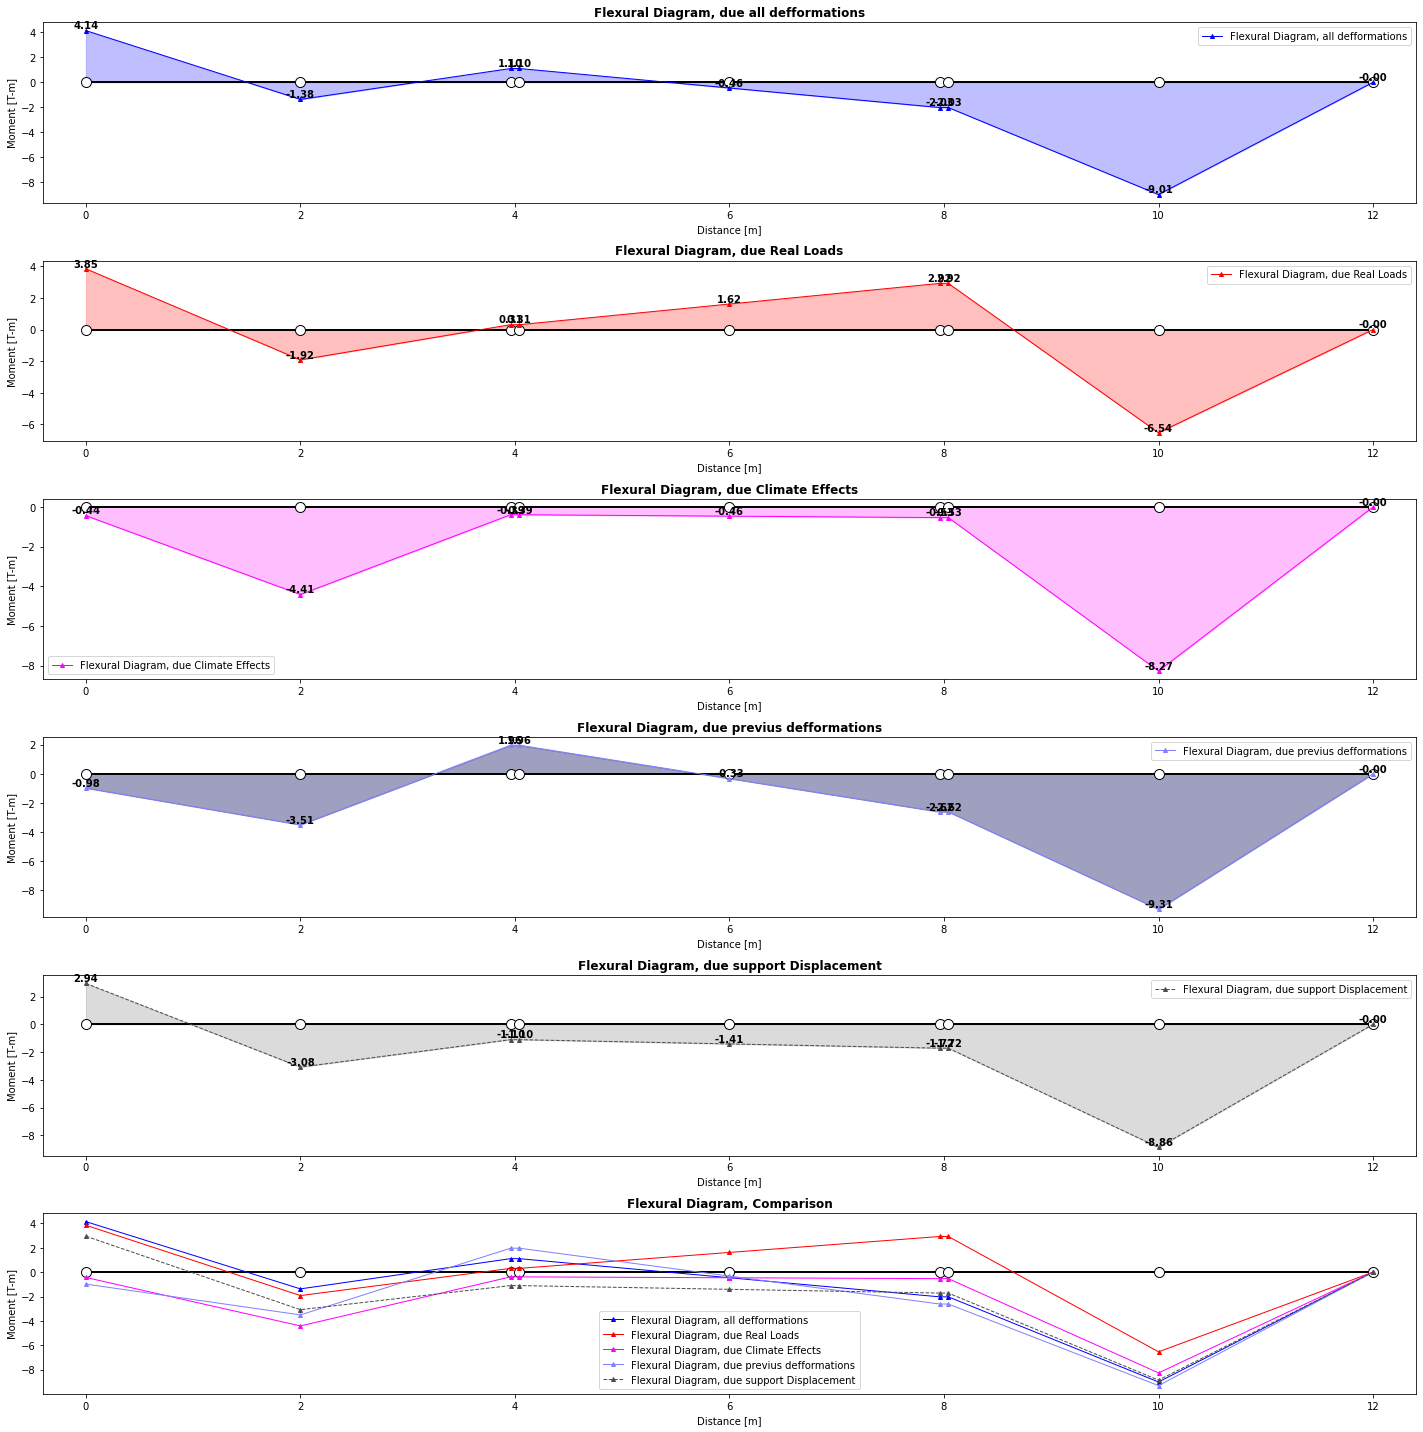

In [17]:
am1 = AM_all.ravel()
am2 = AM_L.ravel()
am3 = AM_T.ravel()
am4 = AM_P.ravel()
am5 = AM_R.ravel()
ylabel = 'Moment [T-m]'

Plot_Flexion = Manual_Flexural_Method(am1 = am1, am2 = am2, am3 = am3, am4 = am4, am5 = am5, X = XF, Y = YF, ylabel = ylabel, L = L)
Plot_Flexion.Plot_AM_Manual_Flexural_Method()

#### Member action vector (Shear) in the real structure

$$\{AM\}=
\{AM_L\}
+
[AM_Q]\{Q\}
$$

Where:

- $\{AM\}$ = member action vector (Shear) in the real structure.
- $\{AM_L\}$ = member action vector (Shear) due to real loads in the released or statically determinate structure.
- $[AM_Q]$ = member action matrix (Shear) due to unit redundants in the released or statically determinate structure.
- $\{Q\}$ = vector of redundants.
![alt text](image-9.png)

##### Calculation of Member action vector (Shear) due to real loads in the released or statically determinate structure $\{AM\}$
![alt text](image-10.png)

In [18]:
AMLv = np.array([[w*L/2],
                 [0],
                 [-w*L/2],
                 [0],
                 [0],
                 [0],
                 [w*L/2],
                 [w*L/2],
                 [-w*L/2],
                 [-w*L/2]])

##### Calculation of Member action matrix (Shear) due to unit redundants in the released or statically determinate structure. $[AM_Q]$
![alt text](image-11.png)

In [19]:
AMQv = np.array([[1/L, 1/L, 0],
                 [1/L, 1/L, 0],
                 [1/L, 1/L, 0],
                 [0, -1/L, 1/L],
                 [0, -1/L, 1/L],
                 [0, -1/L, 1/L],
                 [0, 0, -1/L],
                 [0, 0, -1/L],
                 [0, 0, -1/L],
                 [0, 0, -1/L]])

##### Calculation of Member action vector (Shear) in the real structure $\{AM\} = \{AM_L\}+[AM_Q]\{Q\}$.

In [20]:
#------------Due all deformations---------------
AMv_all = AMLv + (AMQv @ Q_all)
AMv_all_df = pd.DataFrame(AMv_all, columns=['AMv due all deformations'])
#------------only due real loads---------------
AMv_L = AMLv + (AMQv @ Q_L)
AMv_L_df = pd.DataFrame(AMv_L, columns=['AMv due real loads'])
#------------only due climate effects---------------
AMv_T = AMLv + (AMQv @ Q_T)
AMv_T_df = pd.DataFrame(AMv_T, columns=['AMv due climate effects'])
#------------only due previus defformations---------------
AMv_P = AMLv + (AMQv @ Q_P)
AMv_P_df = pd.DataFrame(AMv_P, columns=['AMv due previus defformations'])
#------------only due support diplacement---------------
AMv_R = AMLv + (AMQv @ Q_R)
AMv_R_df = pd.DataFrame(AMv_R, columns=['AMv due support displacement'])

AMv = pd.concat([AMv_all_df, AMv_L_df, AMv_T_df, AMv_P_df, AMv_R_df], axis = 1, ignore_index= False)
AMv

,AMv due all deformations,AMv due real loads,AMv due climate effects,AMv due previus defformations,AMv due support displacement
0,4.760025,4.884615,3.987856,3.263990,5.012013
1,0.760025,0.884615,-0.012144,-0.736010,1.012013
2,-3.239975,-3.115385,-4.012144,-4.736010,-2.987987
3,0.783049,-0.653846,0.036432,1.144904,0.153335
4,0.783049,-0.653846,0.036432,1.144904,0.153335
5,0.783049,-0.653846,0.036432,1.144904,0.153335
6,3.493169,4.730769,3.866414,3.345769,3.570661
7,3.493169,4.730769,3.866414,3.345769,3.570661
8,-4.506831,-3.269231,-4.133586,-4.654231,-4.429339
9,-4.506831,-3.269231,-4.133586,-4.654231,-4.429339


##### For Plotting - SHEAR

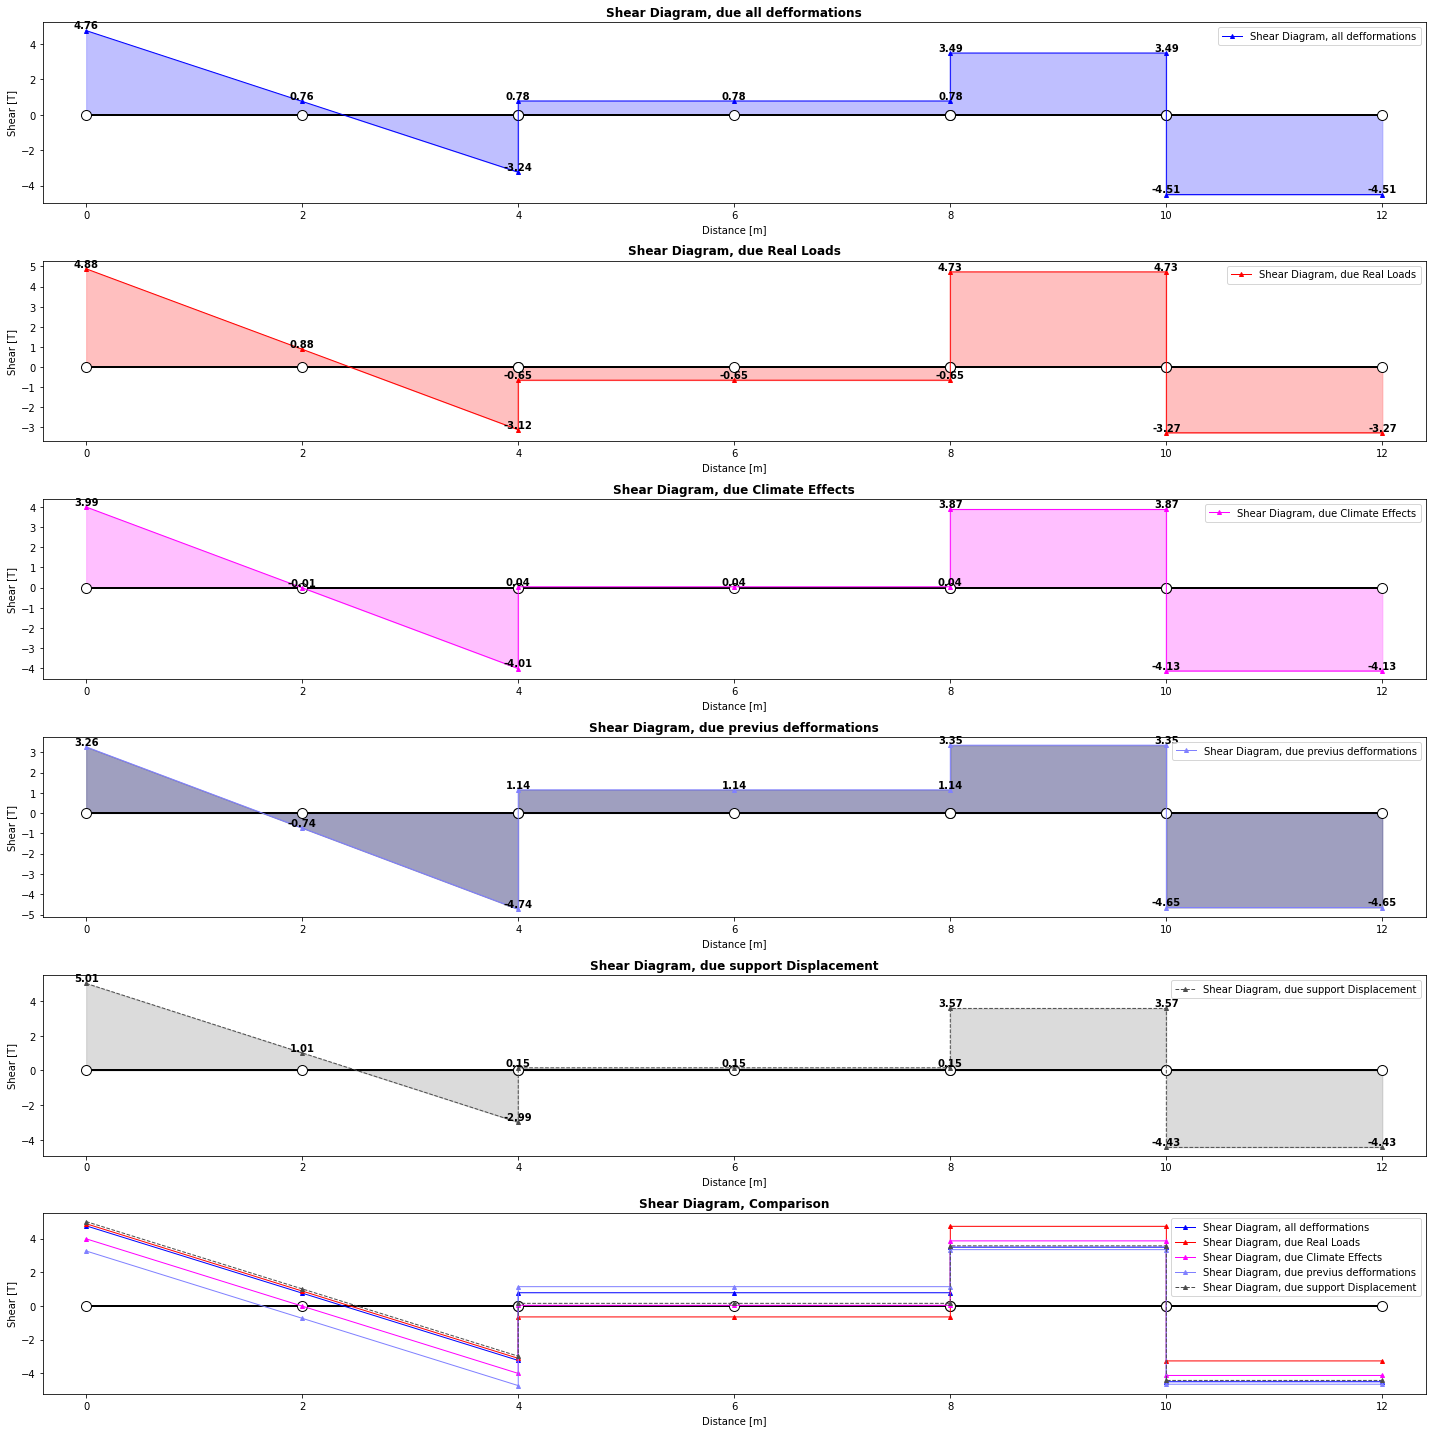

In [21]:
am1 = AMv_all.ravel()
am2 = AMv_L.ravel()
am3 = AMv_T.ravel()
am4 = AMv_P.ravel()
am5 = AMv_R.ravel()
ylabel = 'Shear [T]'

Plot_Shear = Manual_Flexural_Method(am1 = am1, am2 = am2, am3 = am3, am4 = am4, am5 = am5, 
                                    X = XV, Y = YV, ylabel = ylabel, L = L, title = 'Shear')
Plot_Shear.Plot_AM_Manual_Flexural_Method()